[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/user/repo/blob/main/notebook.ipynb)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

# ---- Load RONI (3-month running mean, one value per month, 1950 DJF - 2026 MAM) ----
df = pd.read_csv("../Lecture05&06/noaa_roni.csv")
y = df["RONI"].values
N = len(y)
fs = 12.0                                   # samples per year -> frequency in cycles/yr



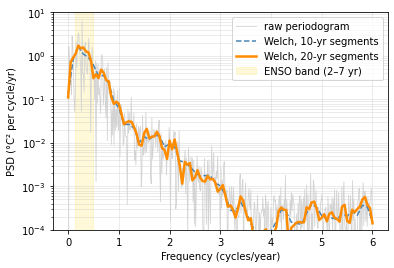

In [2]:
# ---- Raw periodogram and Welch estimates ----
f_raw, P_raw = signal.periodogram(y, fs=fs)
L = 240                                     # Welch segment: 20 years (resolution 0.05 cycles/yr)
f_w, P_w = signal.welch(y, fs=fs, nperseg=L)
L2 = 120                                    # shorter segment for comparison: 10 years, 0.1 cycles/year
f_w2, P_w2 = signal.welch(y, fs=fs, nperseg=L2)


plt.semilogy(f_raw, P_raw, color="lightgray", lw=0.8, label="raw periodogram")
plt.semilogy(f_w2, P_w2, color="steelblue", lw=1.5, ls="--", label="Welch, 10-yr segments")
plt.semilogy(f_w, P_w, color="darkorange", lw=2.5, label="Welch, 20-yr segments")
plt.axvspan(1/7, 1/2, color="gold", alpha=0.15, label="ENSO band (2–7 yr)")
plt.ylabel("PSD (°C² per cycle/yr)")
plt.xlabel("Frequency (cycles/year)")
plt.grid(alpha=0.3, which="both")
plt.ylim(1e-4, 1e1)

plt.legend()

-- hands on --

In [5]:
df = pd.read_csv("./unknown_X.csv", usecols=["day", "x"])
x = df["x"].values
N = len(x)
fs = 365.0            

- how to identify local maximum

### we can then apply pand pass to retrive peak frequency variability
(sosfiltfilt)


(0.0, 3.0)

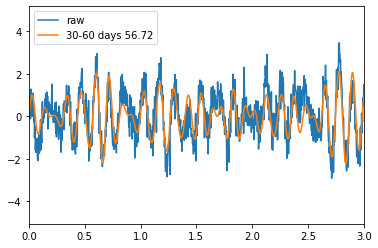

In [6]:

yr = df["day"].values / 365.0
band_1 = [365/60, 365/30] ### since it is around 47.6 days...

sos = signal.butter(4, band_1, btype="bandpass", fs=fs, output="sos")
x_1 = signal.sosfiltfilt(sos, x)
var_1 = 100*x_1.var()/x.var()

plt.plot(yr,x,label='raw')
plt.plot(yr,x_1,label=f"30-60 days {var_1:.2f}")
plt.legend()
plt.xlim(0, 3)

(0.0, 25.0)

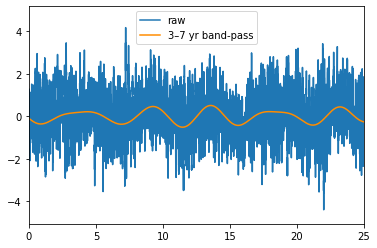

In [7]:
band_2 = [1/7, 1/3] ### since it is around 47.6 days...
sos = signal.butter(4, band_2, btype="bandpass", fs=fs, output="sos")
x_2 = signal.sosfiltfilt(sos, x)

plt.plot(yr,x,label='raw')
plt.plot(yr, x_2, color="darkorange", lw=1.5, label="3–7 yr band-pass")
plt.legend()
plt.xlim(0, 25)


(0.0, 50.0)

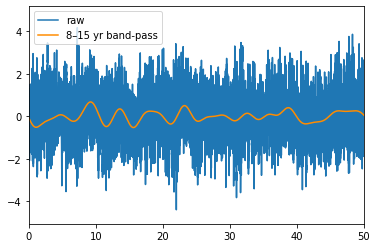

In [8]:
band_3 = [1/15, 1/3] ### since it is around 47.6 days...
sos = signal.butter(4, band_3, btype="bandpass", fs=fs, output="sos")
x_3 = signal.sosfiltfilt(sos, x)

plt.plot(yr,x,label='raw')
plt.plot(yr, x_3, color="darkorange", lw=1.5, label="8–15 yr band-pass")
plt.legend()
plt.xlim(0, 50)
